In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

# Load Transformer results
with open('/home/stud_homes/s3754257/research-project/results/multi_seed/all_results.json', 'r') as f:
    transformer_data = json.load(f)

print("Transformer results loaded.")

Transformer results loaded.


In [2]:
# Signal generators
def sinusoid(t, A, omega, phi):
    return A * np.sin(omega * t + phi)

def triangle(t, A, omega, phi):
    return A * (2 / np.pi) * np.arcsin(np.sin(omega * t + phi))

def square(t, A, omega, phi):
    return A * np.sign(np.sin(omega * t + phi))

# Model-based fitting functions
def fit_sinusoid(t, y_noisy):
    """Fit y = A*sin(omega*t + phi) to noisy data."""
    try:
        popt, _ = curve_fit(sinusoid, t, y_noisy, p0=[1.0, 2*np.pi, 0.0],
                           maxfev=10000)
        return sinusoid(t, *popt), popt
    except:
        return None, None

def fit_triangle(t, y_noisy):
    """Fit triangle wave to noisy data."""
    try:
        popt, _ = curve_fit(triangle, t, y_noisy, p0=[1.0, 2*np.pi, 0.0],
                           maxfev=10000)
        return triangle(t, *popt), popt
    except:
        return None, None

def fit_square_fourier(t, y_noisy, n_harmonics=10):
    """Fit square wave using Fourier series (sum of odd harmonics)."""
    def square_fourier(t, A, omega, phi, *coeffs):
        y = np.zeros_like(t)
        for k in range(n_harmonics):
            n = 2 * k + 1  # odd harmonics: 1, 3, 5, 7...
            if k < len(coeffs):
                y += coeffs[k] * np.sin(n * omega * t + phi)
            else:
                y += (A * 4 / (np.pi * n)) * np.sin(n * omega * t + phi)
        return y
    
    # Simpler: just fit A, omega, phi and use theoretical coefficients
    try:
        popt, _ = curve_fit(lambda t, A, omega, phi: A * np.sign(np.sin(omega * t + phi)),
                           t, y_noisy, p0=[1.0, 2*np.pi, 0.0], maxfev=10000)
        return square(t, *popt), popt
    except:
        return None, None

def fit_delta(t, y_noisy, A=1.0):
    """Model-based delta: find the position of maximum value."""
    pos = np.argmax(np.abs(y_noisy))
    y_fit = np.zeros_like(t)
    y_fit[pos] = A
    return y_fit, [pos]

print("Fitting functions defined.")

Fitting functions defined.


In [3]:
# Run model-based fitting for all signals and noise levels

A_true = 1.0
omega_true = 2 * np.pi
signal_length = 256
dt = 0.01
t = np.arange(signal_length) * dt
noise_levels = [0.0, 0.1, 0.2, 0.5, 1.0]
num_seeds = 10

fit_functions = {
    'sinusoid': fit_sinusoid,
    'triangle': fit_triangle,
    'square': fit_square_fourier,
    'delta': fit_delta,
}

true_signals = {
    'sinusoid': sinusoid(t, A_true, omega_true, 0.0),
    'triangle': triangle(t, A_true, omega_true, 0.0),
    'square': square(t, A_true, omega_true, 0.0),
    'delta': np.zeros(signal_length),  # delta ground truth after spike is zeros
}
# For delta, put spike at center
true_signals['delta'][128] = A_true

model_based_results = {}

for sig_type in ['sinusoid', 'triangle', 'square', 'delta']:
    model_based_results[sig_type] = {}
    
    for sigma in noise_levels:
        maes = []
        
        for seed in range(num_seeds):
            np.random.seed(42 + seed)
            
            # Generate noisy signal
            if sig_type == 'delta':
                position = np.random.randint(signal_length // 4, 3 * signal_length // 4)
                y_true = np.zeros(signal_length)
                y_true[position] = A_true
            else:
                phase = np.random.uniform(0, 2 * np.pi)
                if sig_type == 'sinusoid':
                    y_true = sinusoid(t, A_true, omega_true, phase)
                elif sig_type == 'triangle':
                    y_true = triangle(t, A_true, omega_true, phase)
                elif sig_type == 'square':
                    y_true = square(t, A_true, omega_true, phase)
            
            y_noisy = y_true + np.random.normal(0, sigma, signal_length) if sigma > 0 else y_true.copy()
            
            # Fit model
            if sig_type == 'delta':
                y_fit, params = fit_delta(t, y_noisy, A_true)
                mae = np.mean(np.abs(y_true - y_fit))
            else:
                y_fit, params = fit_functions[sig_type](t, y_noisy)
                if y_fit is not None:
                    mae = np.mean(np.abs(y_true - y_fit))
                else:
                    mae = np.nan
            
            maes.append(mae)
        
        valid_maes = [m for m in maes if not np.isnan(m)]
        model_based_results[sig_type][sigma] = {
            'mae_mean': np.mean(valid_maes),
            'mae_std': np.std(valid_maes),
            'num_valid': len(valid_maes),
        }
        
        print(f"{sig_type} σ={sigma}: MB MAE = {np.mean(valid_maes):.4f} ± {np.std(valid_maes):.4f}")

print("\nModel-based fitting complete!")

sinusoid σ=0.0: MB MAE = 0.0000 ± 0.0000
sinusoid σ=0.1: MB MAE = 0.0091 ± 0.0039
sinusoid σ=0.2: MB MAE = 0.0183 ± 0.0078
sinusoid σ=0.5: MB MAE = 0.0460 ± 0.0197
sinusoid σ=1.0: MB MAE = 0.0928 ± 0.0401
triangle σ=0.0: MB MAE = 0.0000 ± 0.0000
triangle σ=0.1: MB MAE = 0.0091 ± 0.0038
triangle σ=0.2: MB MAE = 0.0183 ± 0.0078
triangle σ=0.5: MB MAE = 0.0466 ± 0.0236
triangle σ=1.0: MB MAE = 0.1044 ± 0.0521
square σ=0.0: MB MAE = 0.6011 ± 0.3766
square σ=0.1: MB MAE = 0.6011 ± 0.3773
square σ=0.2: MB MAE = 0.6011 ± 0.3780
square σ=0.5: MB MAE = 0.6009 ± 0.3800
square σ=1.0: MB MAE = 0.6229 ± 0.3646
delta σ=0.0: MB MAE = 0.0000 ± 0.0000
delta σ=0.1: MB MAE = 0.0000 ± 0.0000
delta σ=0.2: MB MAE = 0.0008 ± 0.0023
delta σ=0.5: MB MAE = 0.0055 ± 0.0036
delta σ=1.0: MB MAE = 0.0078 ± 0.0000

Model-based fitting complete!


/tmp/ipykernel_4102787/1856031392.py:44: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(lambda t, A, omega, phi: A * np.sign(np.sin(omega * t + phi)),


In [4]:
# Comparison table: Model-Based vs Transformer

print("=" * 90)
print("MODEL-BASED vs TRANSFORMER (MAE, mean ± std, 10 seeds)")
print("=" * 90)

for sig_type in ['sinusoid', 'triangle', 'square', 'delta']:
    print(f"\n--- {sig_type.upper()} ---")
    print(f"{'σ':<8} {'Model-Based MAE':<25} {'Transformer MAE':<25} {'Winner':<10}")
    print("-" * 68)
    
    for sigma in noise_levels:
        mb = model_based_results[sig_type][sigma]
        tr_runs = transformer_data[sig_type][str(sigma)]
        tr_maes = [r['mae'] for r in tr_runs]
        tr_mean = np.mean(tr_maes)
        tr_std = np.std(tr_maes)
        
        winner = "MB" if mb['mae_mean'] < tr_mean else "Transformer"
        
        print(f"{sigma:<8} "
              f"{mb['mae_mean']:.4f} ± {mb['mae_std']:.4f}        "
              f"{tr_mean:.4f} ± {tr_std:.4f}        "
              f"{winner}")

MODEL-BASED vs TRANSFORMER (MAE, mean ± std, 10 seeds)

--- SINUSOID ---
σ        Model-Based MAE           Transformer MAE           Winner    
--------------------------------------------------------------------
0.0      0.0000 ± 0.0000        0.0142 ± 0.0179        MB
0.1      0.0091 ± 0.0039        0.1686 ± 0.1523        MB
0.2      0.0183 ± 0.0078        0.2265 ± 0.1415        MB
0.5      0.0460 ± 0.0197        0.5257 ± 0.1730        MB
1.0      0.0928 ± 0.0401        0.9580 ± 0.1797        MB

--- TRIANGLE ---
σ        Model-Based MAE           Transformer MAE           Winner    
--------------------------------------------------------------------
0.0      0.0000 ± 0.0000        0.0146 ± 0.0335        MB
0.1      0.0091 ± 0.0038        0.0992 ± 0.0112        MB
0.2      0.0183 ± 0.0078        0.2094 ± 0.0628        MB
0.5      0.0466 ± 0.0236        0.4229 ± 0.0525        MB
1.0      0.1044 ± 0.0521        0.9145 ± 0.1107        MB

--- SQUARE ---
σ        Model-Based MAE       

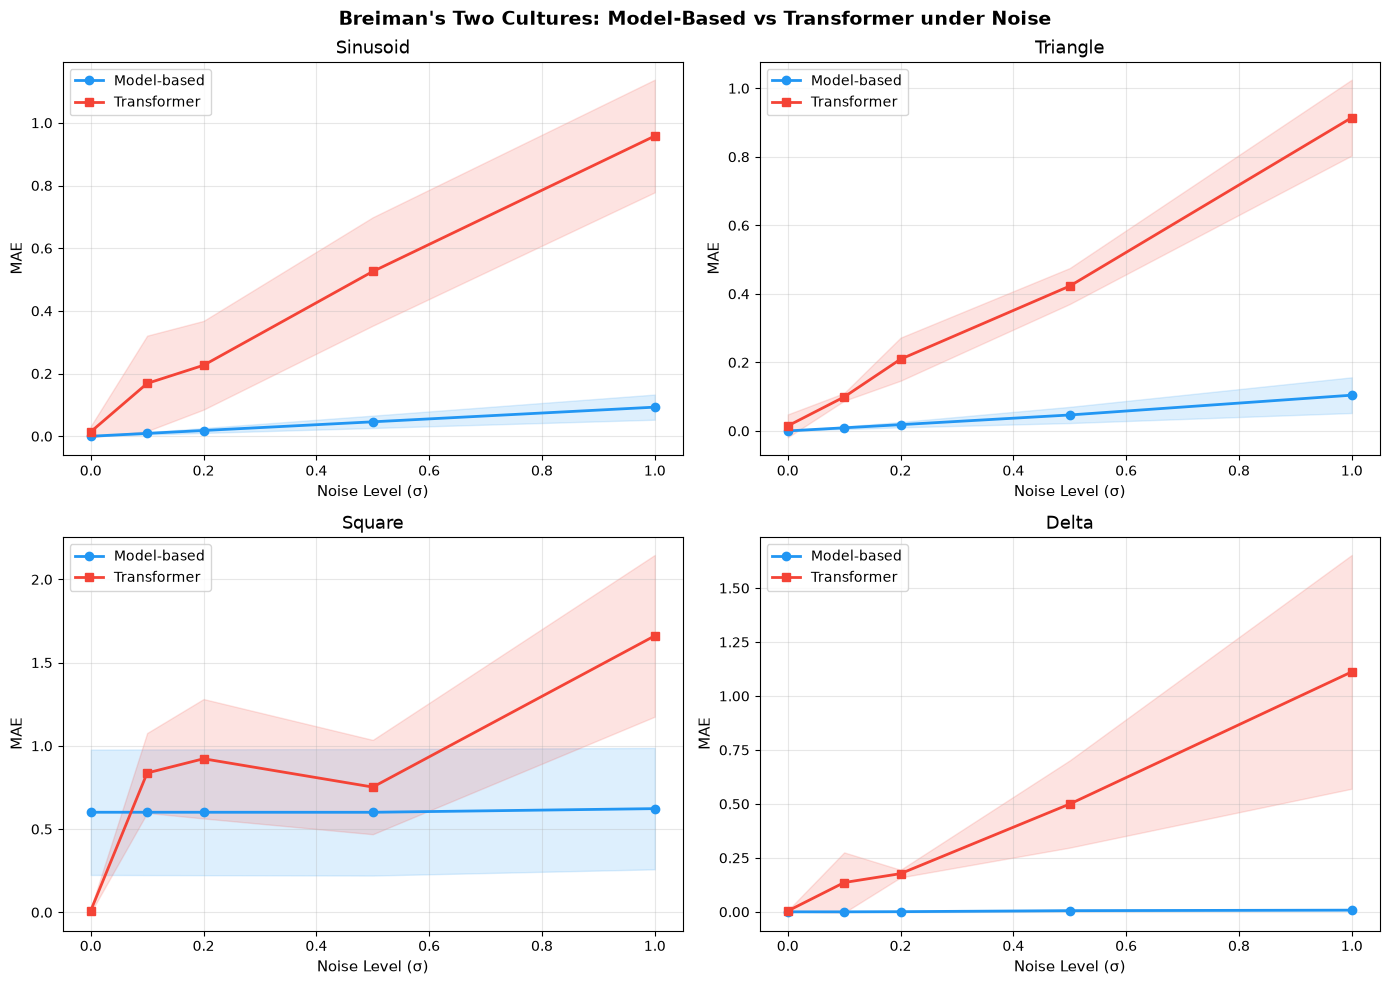

Plot saved!


In [5]:
# Plot: Model-Based vs Transformer MAE

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_mb = '#2196F3'
colors_tr = '#F44336'

for i, sig_type in enumerate(['sinusoid', 'triangle', 'square', 'delta']):
    ax = axes[i // 2][i % 2]
    
    mb_means = [model_based_results[sig_type][s]['mae_mean'] for s in noise_levels]
    mb_stds = [model_based_results[sig_type][s]['mae_std'] for s in noise_levels]
    
    tr_means = []
    tr_stds = []
    for sigma in noise_levels:
        runs = transformer_data[sig_type][str(sigma)]
        maes = [r['mae'] for r in runs]
        tr_means.append(np.mean(maes))
        tr_stds.append(np.std(maes))
    
    mb_means = np.array(mb_means)
    mb_stds = np.array(mb_stds)
    tr_means = np.array(tr_means)
    tr_stds = np.array(tr_stds)
    
    ax.plot(noise_levels, mb_means, 'o-', color=colors_mb, label='Model-based', linewidth=2)
    ax.fill_between(noise_levels, mb_means - mb_stds, mb_means + mb_stds, alpha=0.15, color=colors_mb)
    
    ax.plot(noise_levels, tr_means, 's-', color=colors_tr, label='Transformer', linewidth=2)
    ax.fill_between(noise_levels, tr_means - tr_stds, tr_means + tr_stds, alpha=0.15, color=colors_tr)
    
    ax.set_xlabel('Noise Level (σ)', fontsize=11)
    ax.set_ylabel('MAE', fontsize=11)
    ax.set_title(f'{sig_type.capitalize()}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Breiman's Two Cultures: Model-Based vs Transformer under Noise", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/stud_homes/s3754257/research-project/plots/model_based_vs_transformer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

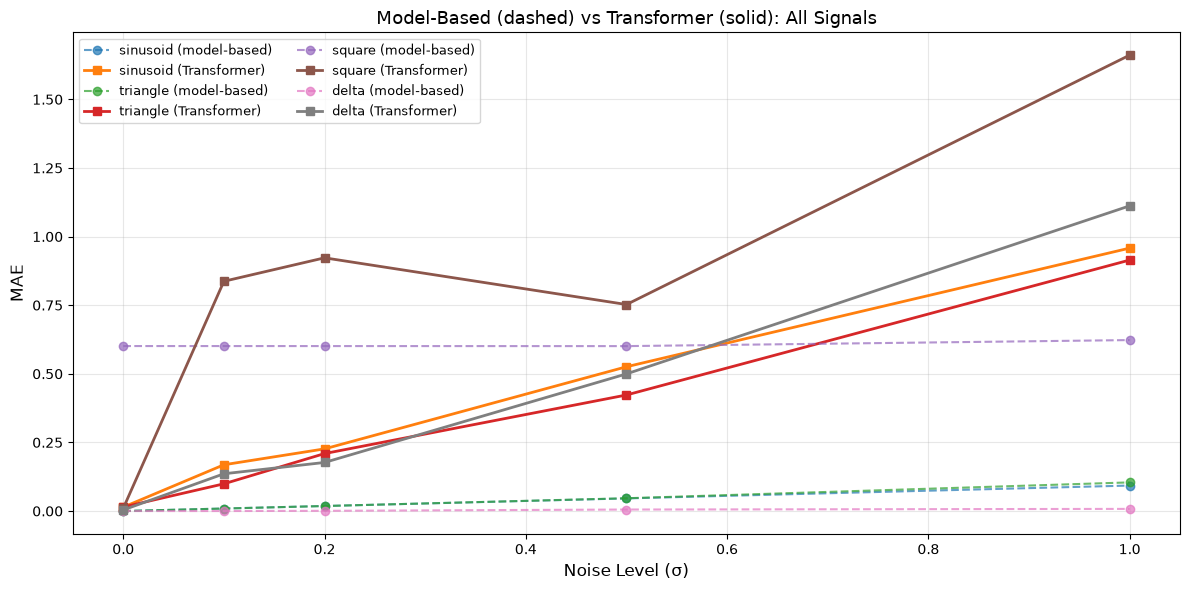

Plot saved!


In [7]:
# Summary plot: all signals on one axis

fig, ax = plt.subplots(figsize=(12, 6))

for sig_type in ['sinusoid', 'triangle', 'square', 'delta']:
    mb_means = [model_based_results[sig_type][s]['mae_mean'] for s in noise_levels]
    tr_means = [np.mean([r['mae'] for r in transformer_data[sig_type][str(s)]]) for s in noise_levels]
    
    ax.plot(noise_levels, mb_means, 'o--', label=f'{sig_type} (model-based)', linewidth=1.5, alpha=0.7)
    ax.plot(noise_levels, tr_means, 's-', label=f'{sig_type} (Transformer)', linewidth=2)

ax.set_xlabel('Noise Level (σ)', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title("Model-Based (dashed) vs Transformer (solid): All Signals", fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/stud_homes/s3754257/research-project/plots/model_based_vs_transformer_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")